In [1]:
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
df1 = pd.read_csv('../ncbi_562_data.csv')
df2 = pd.read_csv('../ncbi_590_data.csv')

C:\Users\bryan\AppData\Local\Temp\ipykernel_20760\3309735490.py:6: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  df2 = pd.read_csv('../ncbi_590_data.csv')


In [2]:
df1 = df1[df1['is_usa_based'] == 1]
df1['collection_year'] = pd.to_numeric(df1['collection_year'], errors='coerce')
df1 = df1[df1['collection_year'] >= 2009]
df2 = df2[df2['is_usa_based'] == 1]
df2['collection_year'] = pd.to_numeric(df2['collection_year'], errors='coerce')
df2 = df2[df2['collection_year'] >= 2009]

In [3]:
df1_states = df1['usa_state'].value_counts()
df2_states = df2['usa_state'].value_counts()

In [4]:
#Fix the casing on usa_state so it's proper
df1_states.index = df1_states.index.str.title()
df2_states.index = df2_states.index.str.title()

In [5]:
df1_states = df1_states.reset_index()
df1_states.columns = ['usa_state', 'count']
df1_states = df1_states.groupby('usa_state')['count'].sum()
df2_states = df2_states.reset_index()
df2_states.columns = ['usa_state', 'count']
df2_states = df2_states.groupby('usa_state')['count'].sum()
df1_states = df1_states.sort_values(ascending=False)
df2_states = df2_states.sort_values(ascending=False)

In [6]:
#Leave out "Unknown", "Other"
df1_states = df1_states[~df1_states.index.isin(["Unknown", "No State", "Washington Dc", "Puerto Rico", "Guam"])]
df2_states = df2_states[~df2_states.index.isin(["Unknown", "No State", "Washington Dc", "Puerto Rico", "Guam"])]



In [7]:
df1_states = df1_states.reset_index()
df1_states.columns = ['usa_state', 'count']
df2_states = df2_states.reset_index()
df2_states.columns = ['usa_state', 'count']

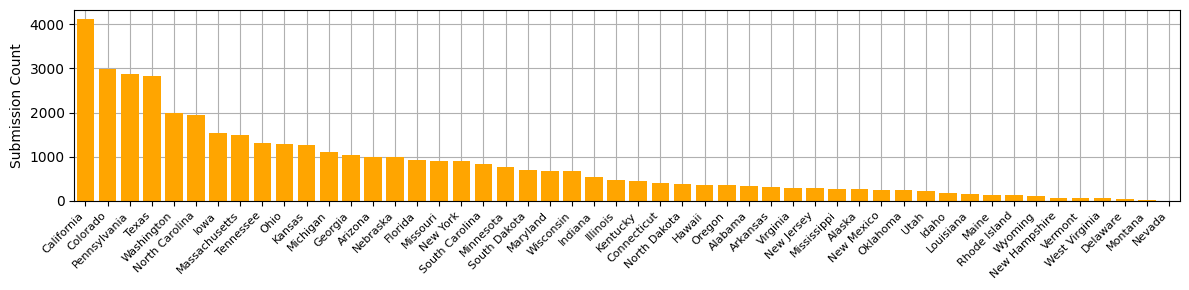

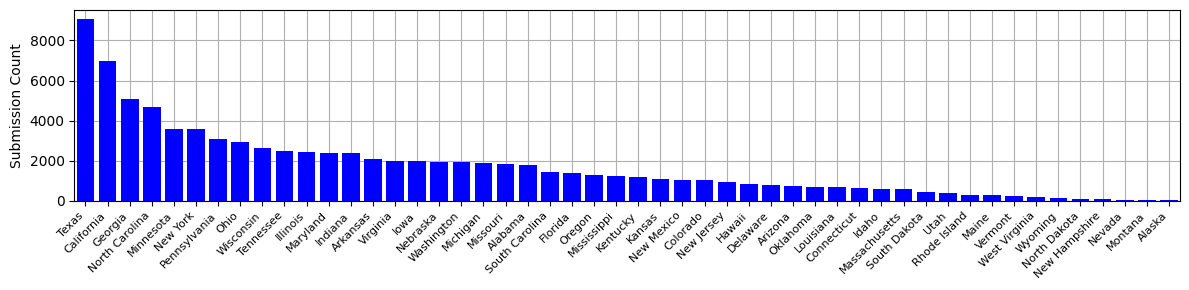

In [8]:
# Make a bar chart for df1_states

plt.figure(figsize=(12, 3))

plt.bar(df1_states['usa_state'], df1_states['count'], color='orange')
plt.title('')
#place the bars in front of the grid
plt.gca().set_axisbelow(True)
plt.grid(axis='both')
plt.xlim(-0.5, len(df1_states) - 0.5)
plt.ylabel('Submission Count')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.savefig('../outputs/top_states_count_562.tiff', dpi=300)
plt.show()

# Make a bar chart for df2_states
plt.figure(figsize=(12, 3))
plt.bar(df2_states['usa_state'], df2_states['count'], color='blue')
plt.title('')
plt.gca().set_axisbelow(True)
plt.grid(axis='both')
plt.xlim(-0.5, len(df2_states) - 0.5)
plt.ylabel('Submission Count')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.savefig('../outputs/top_states_count_590.tiff', dpi=300)
plt.show()

In [9]:
#put df1_states and df2_states in abc order by usa_states descending
df1_states = df1_states.sort_values(by='usa_state', ascending=True).reset_index(drop=True)
df2_states = df2_states.sort_values(by='usa_state', ascending=True).reset_index(drop=True)

In [10]:
#make df1_norm_states that takes df1 and divides the counts by the numbers in ../lookup_tables/state_pop_2023.csv
state_pop = pd.read_csv('../lookup_tables/state_pop_2023.csv')
df1_norm_states = df1_states.copy()
df1_norm_states['count'] = df1_norm_states['count'] / state_pop['Population (Millions)']
df2_norm_states = df2_states.copy()
df2_norm_states['count'] = df2_norm_states['count'] / state_pop['Population (Millions)']
df1_norm_states = df1_norm_states.sort_values(by='count', ascending=False).reset_index(drop=True)
df2_norm_states = df2_norm_states.sort_values(by='count', ascending=False).reset_index(drop=True)

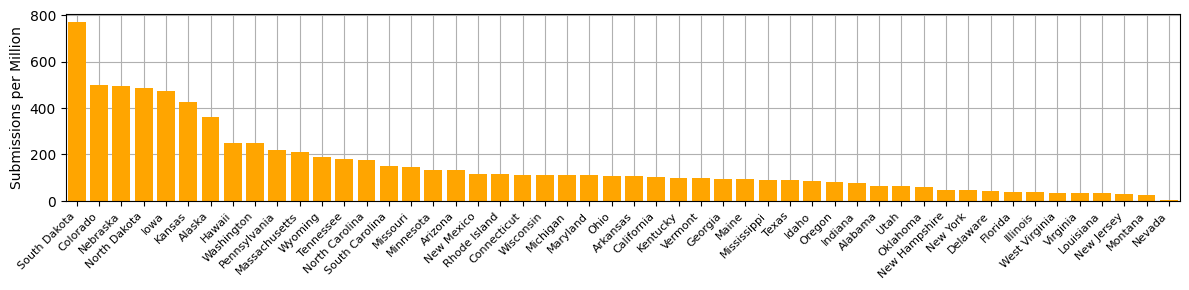

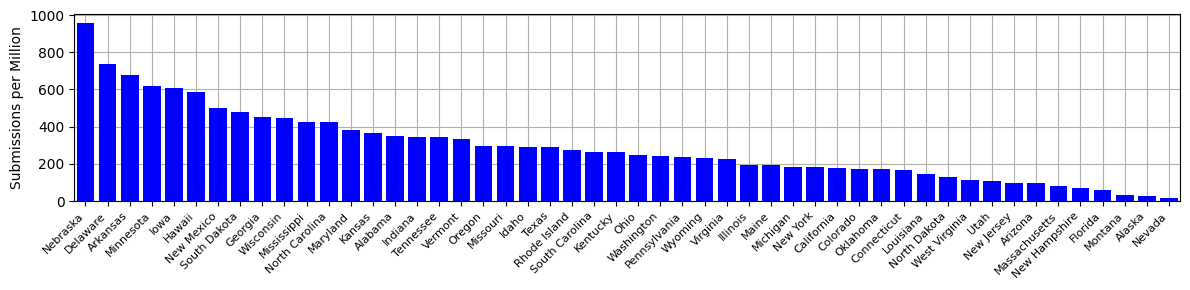

In [11]:
# Make a bar chart for df1_states

plt.figure(figsize=(12, 3))
plt.bar(df1_norm_states['usa_state'], df1_norm_states['count'], color='orange')
plt.title('')
#place the bars in front of the grid
plt.gca().set_axisbelow(True)
plt.grid(axis='both')
plt.xlim(-0.5, len(df1_states) - 0.5)
plt.ylabel('Submissions per Million')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.savefig('../outputs/top_states_count_per_cap_562.tiff', dpi=300)
plt.show()

# Make a bar chart for df2_states
plt.figure(figsize=(12, 3))
plt.bar(df2_norm_states['usa_state'], df2_norm_states['count'], color='blue')
plt.title('')
plt.gca().set_axisbelow(True)
plt.grid(axis='both')
plt.xlim(-0.5, len(df2_states) - 0.5)
plt.ylabel('Submissions per Million')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.savefig('../outputs/top_states_count_per_cap_590.tiff', dpi=300)
plt.show()